In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sro_sto_plume import microscopy as mic

# Target Microscopy Surface Roughness Review

This notebook aggregates the ROI definitions used during microscopy QA, renders each height map with the inspection polygons, and summarizes standard roughness metrics (Ra, Rq, Rz, mean height). Use the sections below to:

1. Configure scan areas and regions of interest (ROIs).
2. Inspect individual scans to sanity-check the polygons and roughness calculations.
3. Combine all scans for comparisons across treatments, scan areas, and ROI fragments.
4. Visualize the distributions and trends in multiple complementary ways (line plots, heatmaps, violins, PCA, etc.).

In [2]:
# --- 1. Configuration and ROI catalog ---
DATA_ROOT = Path("../data/TargetMicroscopy/selected")

# When True, remove a best-fit plane from each ROI before computing roughness
# metrics. This flattens tilt/bow so Ra/Rq/Rz reflect only local texture.
DETREND_ROI = True

# Map each scan area to the ROIs we want to analyze. Each entry is either
# (polygon, descriptive label) or a dict with "polygon" and optional "label" keys.
combined_sample_dict = {
    'Area0': [
        ([(0.0, 0.0), (830.0, 0.0), (830.0, 830.0), (0.0, 830.0)], 'Area0-Sanded'),
    ],
    'Area1': [
        ([(5.0, 5.0), (830.0, 5.0), (830.0, 830.0), (5.0, 830.0)], 'Area1-Avg'),
        ([(5.0, 5.0), (410.0, 5.0), (410.0, 830.0), (5.0, 830.0)], 'Area1-G1'),
        ([(550.0, 5.0), (830.0, 5.0), (830.0, 830.0), (550.0, 830.0)], 'Area1-Sanded'),
        ([(5.0, 5.0), (400.0, 5.0), (410.0, 350.0), (5.0, 200.0)], 'Area1-G1-small'),
        ([(500.0, 400.0), (830.0, 500.0), (830.0, 830.0), (550.0, 830.0)], 'Area1-Sanded-small'),
    ],
    'Area2': [
        ([(5.0, 5.0), (830.0, 5.0), (830.0, 830.0), (5.0, 830.0)], 'Area2-Avg'),
        ([(500.0, 5.0), (830.0, 5.0), (830.0, 830.0), (500.0, 830.0)], 'Area2-Sanded-1'),
        ([(450.0, 0.0), (830.0, 0.0), (830.0, 830.0), (550.0, 830.0)], 'Area2-Sanded-2'),
        ([(5.0, 5.0), (310.0, 5.0), (310.0, 830.0), (5.0, 830.0)], 'Area2-G2'),
        ([(5.0, 650.0), (150.0, 400.0), (280.0, 830.0), (5.0, 830.0)], 'Area2-G2-small'),
    ],
    'Area3': [
        ([(5.0, 5.0), (830.0, 5.0), (830.0, 830.0), (5.0, 830.0)], 'Area3-Avg'),
        ([(5.0, 5.0), (340.0, 5.0), (360.0, 220.0), (5.0, 830.0)], 'Area3-G3-1'),
        ([(520.0, 5.0), (830.0, 5.0), (830.0, 400.0), (450.0, 400.0)], 'Area3-G3-2'),
    ],
    'Area4': [
        ([(5.0, 5.0), (830.0, 5.0), (830.0, 830.0), (5.0, 830.0)], 'Area4-Avg'),
        ([(5.0, 5.0), (830.0, 5.0), (830.0, 180.0), (5.0, 270.0)], 'Area4-Sanded'),
        ([(100.0, 120.0), (830.0, 100.0), (800.0, 180.0), (5.0, 270.0)], 'Area4-Sanded-small'),
        ([(5.0, 330.0), (830.0, 230.0), (830.0, 830.0), (5.0, 830.0)], 'Area4-G4'),
    ],
    'Area5': [
        ([(5.0, 5.0), (830.0, 5.0), (830.0, 830.0), (5.0, 830.0)], 'Area5-Avg'),
        ([(5.0, 180.0), (830.0, 80.0), (830.0, 830.0), (5.0, 830.0)], 'Area5-G5'),
        ([(5.0, 5.0), (500.0, 5.0), (500.0, 30.0), (5.0, 100.0)], 'Area5-Sanded'),
    ],
}

# Select which scan areas to inspect in detail above and beyond the combined analysis.
AREAS_TO_INSPECT = list(combined_sample_dict.keys())  # edit this list to focus on specific scans



## 2. Per-scan inspection

Each scan is flattened (best-fit plane removed) before computing roughness metrics so that tilt/bow do not inflate Ra/Rq/Rz.

=== Area0 ===


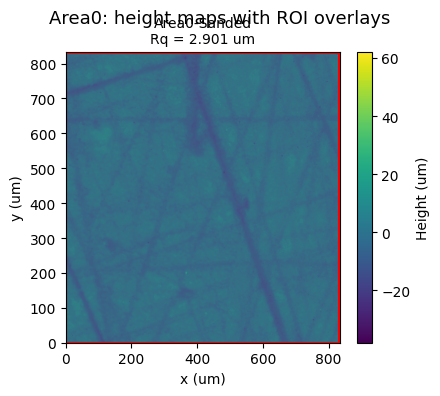

,label,treatment,roi_fragment,Ra,Rq,Rz,mean,detrended
0,Area0-Sanded,Sanded,unknown,2.195922,2.900887,100.359928,-8.812606e-17,True


=== Area1 ===


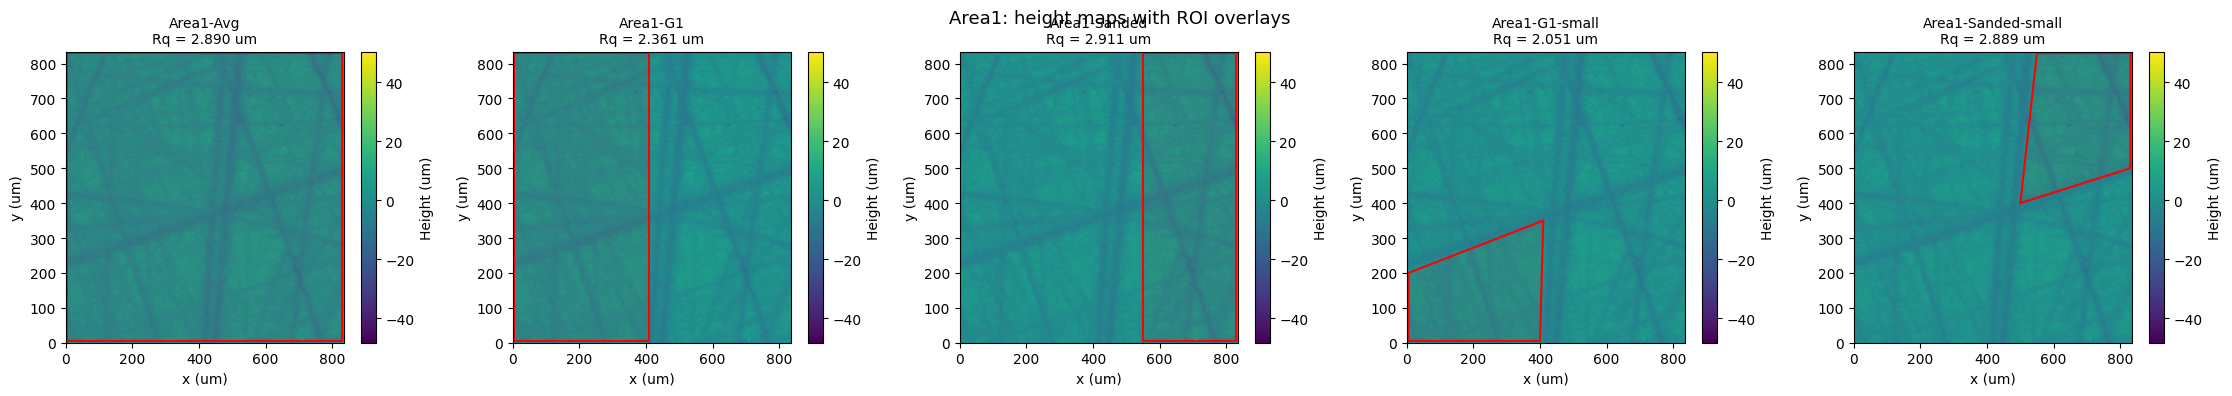

,label,treatment,roi_fragment,Ra,Rq,Rz,mean,detrended
0,Area1-Avg,Avg,unknown,2.295148,2.890180,98.847844,1.228771e-16,True
1,Area1-G1,G1,unknown,1.867576,2.361497,79.837737,-1.847701e-16,True
2,Area1-Sanded,Sanded,unknown,2.288163,2.910703,97.540927,-1.848114e-14,True
3,Area1-G1-small,G1,small,1.619917,2.051384,51.350392,9.411454e-16,True
4,Area1-Sanded-small,Sanded,small,2.215459,2.888641,97.417763,-2.262221e-14,True


=== Area2 ===


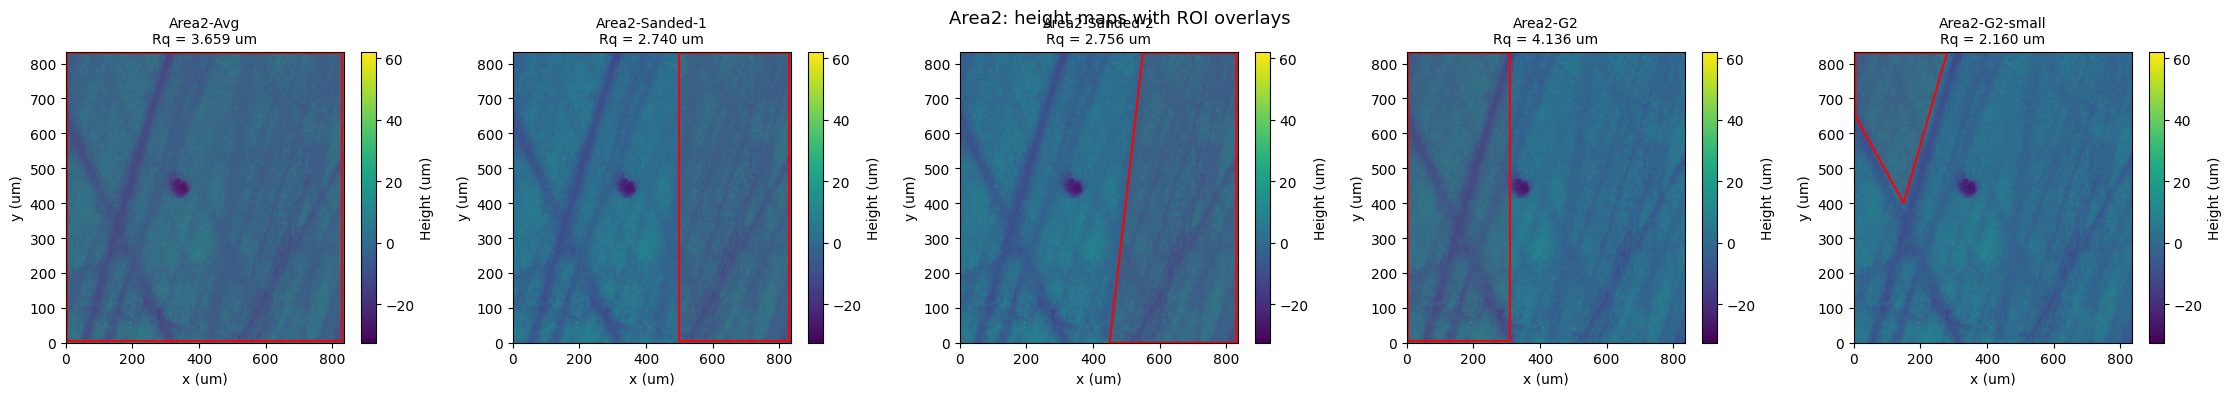

,label,treatment,roi_fragment,Ra,Rq,Rz,mean,detrended
0,Area2-Avg,Avg,unknown,2.751199,3.659257,93.633572,-4.368583e-16,True
1,Area2-Sanded-1,Sanded,1,2.131014,2.740114,76.191586,1.833840e-14,True
2,Area2-Sanded-2,Sanded,2,2.147070,2.756289,76.347542,2.292942e-14,True
3,Area2-G2,G2,unknown,3.322059,4.136253,87.135802,3.631540e-16,True
4,Area2-G2-small,G2,small,1.662365,2.159581,59.500122,-2.151136e-14,True


=== Area3 ===


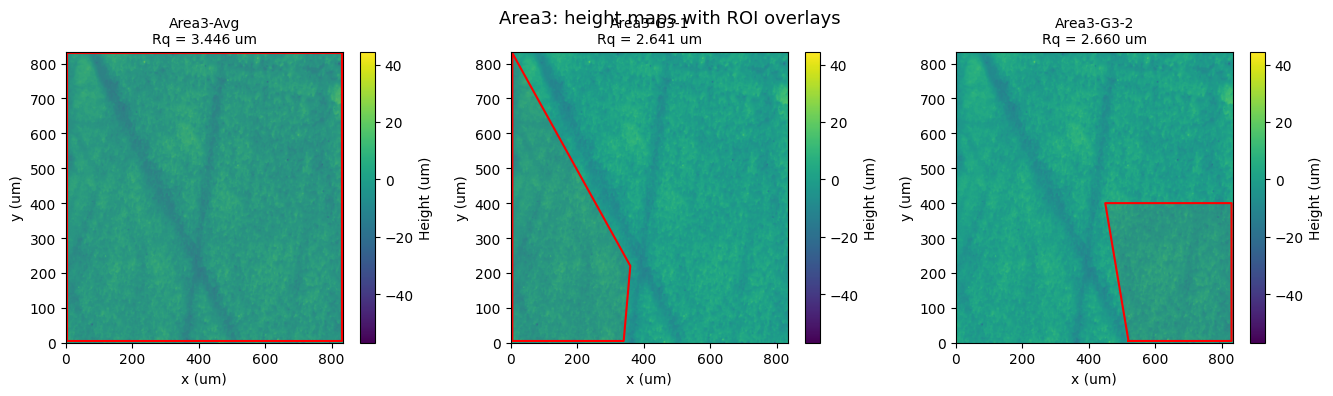

,label,treatment,roi_fragment,Ra,Rq,Rz,mean,detrended
0,Area3-Avg,Avg,unknown,2.671374,3.445933,99.721039,5.499888e-16,True
1,Area3-G3-1,G3,1,2.089212,2.641122,76.444587,5.551115e-16,True
2,Area3-G3-2,G3,2,2.109719,2.659533,80.059898,5.283619e-15,True


=== Area4 ===


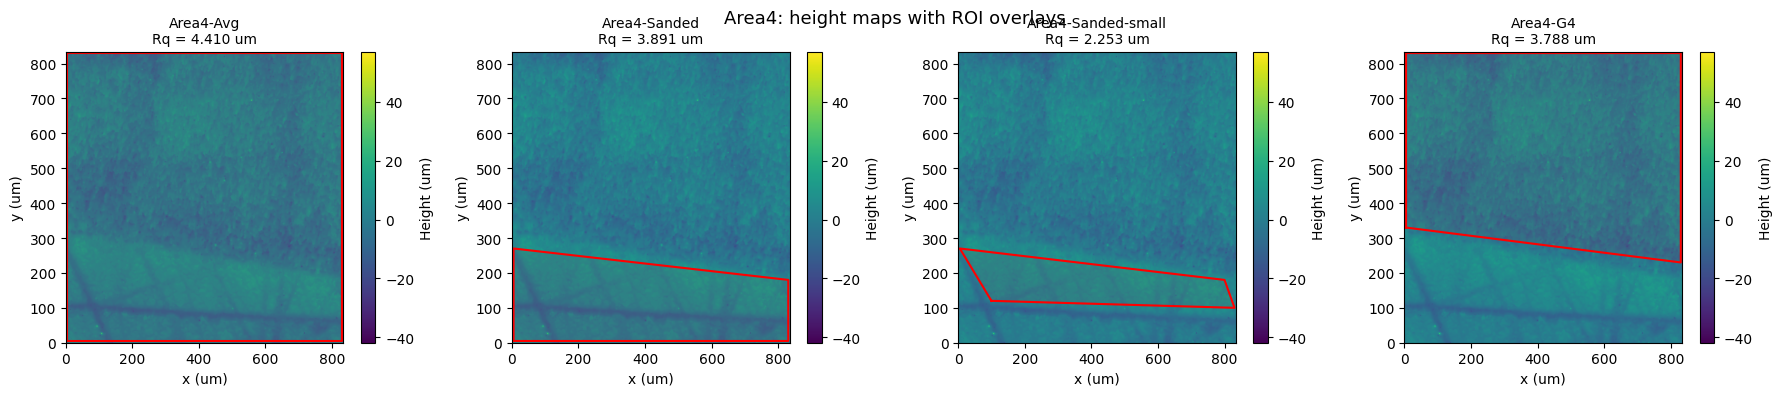

,label,treatment,roi_fragment,Ra,Rq,Rz,mean,detrended
0,Area4-Avg,Avg,unknown,3.543511,4.410469,99.080185,-2.552633e-16,True
1,Area4-Sanded,Sanded,unknown,3.013867,3.890753,101.919122,-5.747930e-15,True
2,Area4-Sanded-small,Sanded,small,1.792635,2.252647,48.766606,-1.267653e-12,True
3,Area4-G4,G4,unknown,2.998777,3.787638,94.945464,-5.332906e-14,True


=== Area5 ===


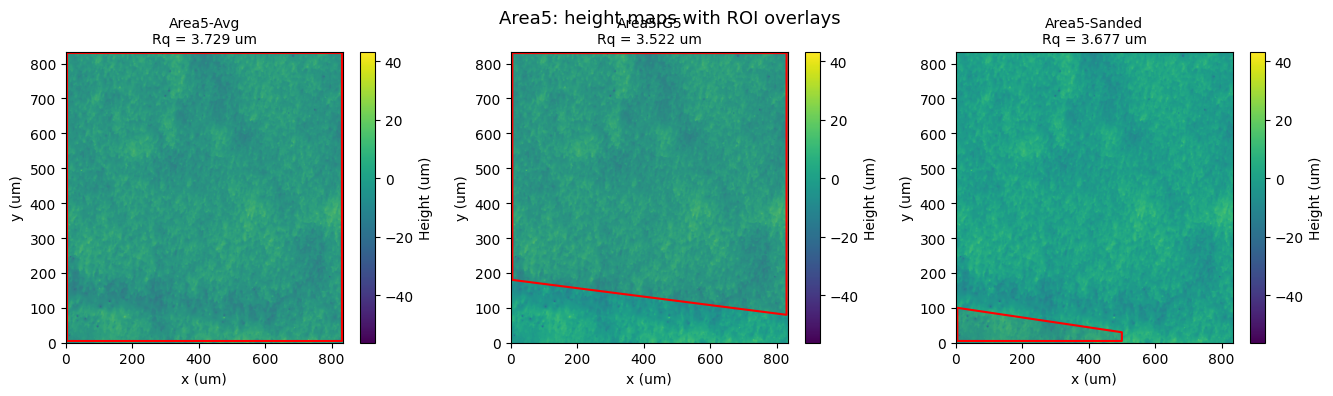

,label,treatment,roi_fragment,Ra,Rq,Rz,mean,detrended
0,Area5-Avg,Avg,unknown,2.942870,3.728972,99.522243,-4.283267e-16,True
1,Area5-G5,G5,unknown,2.781486,3.522374,99.647232,1.074505e-14,True
2,Area5-Sanded,Sanded,unknown,2.844253,3.676912,85.330841,3.852792e-14,True


In [3]:
per_area_tables = {}

for area in AREAS_TO_INSPECT:
    print(f"=== {area} ===")
    surfaces = mic.build_surfaces(combined_sample_dict, area=area, data_root=DATA_ROOT)

    results, fig = mic.analyze_surfaces(
        surfaces,
        polygon_unit='um',
        roughness_unit='um',
        xy_unit='um',
        z_unit='um',
        max_cols=5,
        detrend=DETREND_ROI,
    )
    fig.suptitle(f"{area}: height maps with ROI overlays", fontsize=13)
    plt.show()

    single_df = pd.DataFrame(results)
    split_cols = single_df['label'].str.split('-', expand=True)
    split_cols = split_cols.reindex(columns=range(3))  # force columns 0,1,2
    split_cols = split_cols.fillna('unknown')

    single_df['area'] = split_cols[0]
    single_df['treatment'] = split_cols[1]
    single_df['roi_fragment'] = split_cols[2]

    per_area_tables[area] = single_df
    display(single_df[['label', 'treatment', 'roi_fragment', 'Ra', 'Rq', 'Rz', 'mean', 'detrended']])

## 3. Selected scan area comparison

Pull a subset of ROIs (already flattened) for quick side-by-side inspection across growth generations.

In [4]:
selected_labels = ['Area0-Sanded', 'Area1-G1', 'Area2-G2-small', 'Area3-G3-1', 'Area4-G4', 'Area5-G5']
selected_df = pd.concat(
    [df[df['label'].isin(selected_labels)] for df in per_area_tables.values()],
    ignore_index=True
)
selected_df = selected_df.sort_values(by=['area', 'treatment', 'roi_fragment'])
display(selected_df[['label', 'area', 'treatment', 'roi_fragment', 'Ra', 'Rq', 'Rz', 'mean', 'detrended']])


,label,area,treatment,roi_fragment,Ra,Rq,Rz,mean,detrended
0,Area0-Sanded,Area0,Sanded,unknown,2.195922,2.900887,100.359928,-8.812606e-17,True
1,Area1-G1,Area1,G1,unknown,1.867576,2.361497,79.837737,-1.847701e-16,True
2,Area2-G2-small,Area2,G2,small,1.662365,2.159581,59.500122,-2.151136e-14,True
3,Area3-G3-1,Area3,G3,1,2.089212,2.641122,76.444587,5.551115e-16,True
4,Area4-G4,Area4,G4,unknown,2.998777,3.787638,94.945464,-5.332906e-14,True
5,Area5-G5,Area5,G5,unknown,2.781486,3.522374,99.647232,1.074505e-14,True


Rq                  Ra                    Rz          
               mean std count      mean std count        mean std count
treatment                                                              
G4         3.787638 NaN     1  2.998777 NaN     1   94.945464 NaN     1
G5         3.522374 NaN     1  2.781486 NaN     1   99.647232 NaN     1
Sanded     2.900887 NaN     1  2.195922 NaN     1  100.359928 NaN     1
G3         2.641122 NaN     1  2.089212 NaN     1   76.444587 NaN     1
G1         2.361497 NaN     1  1.867576 NaN     1   79.837737 NaN     1
G2         2.159581 NaN     1  1.662365 NaN     1   59.500122 NaN     1

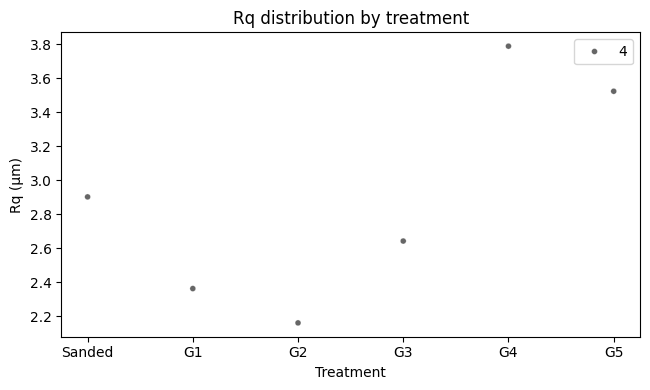

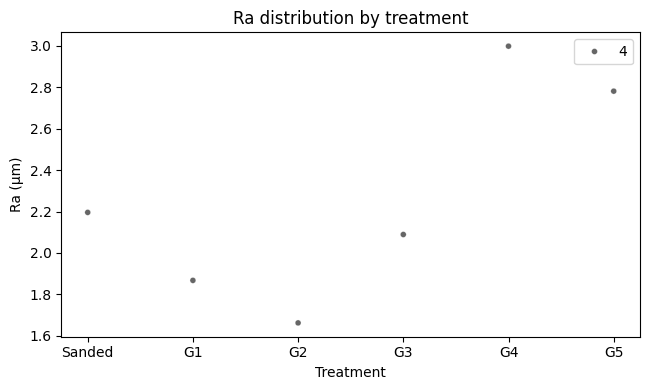

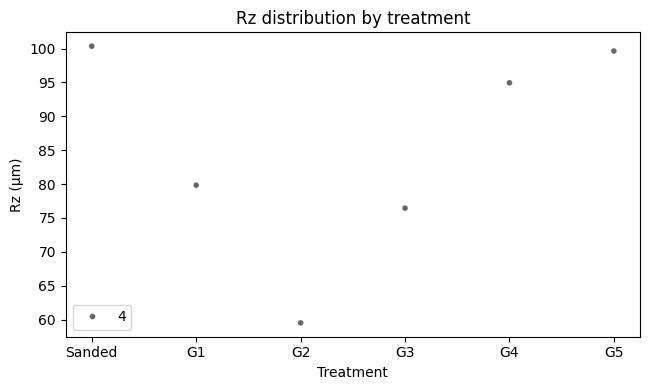

In [5]:
def summarize_and_plot(df, group_col, metrics=('Rq', 'Ra', 'Rz')):
    """Print mean/std/count tables and draw violin plots for the requested metrics."""
    summary = df.groupby(group_col)[list(metrics)].agg(['mean', 'std', 'count'])
    display(summary.sort_values((metrics[0], 'mean'), ascending=False))

    for metric in metrics:
        order = summary.index.tolist()
        fig, ax = plt.subplots(figsize=(max(6, len(order) * 1.1), 4))
        sns.scatterplot(data=df, x=group_col, y=metric, ax=ax, color='black', size=4, alpha=0.6)
        ax.set_title(f"{metric} distribution by {group_col}")
        ax.set_xlabel(group_col.capitalize())
        ax.set_ylabel(f"{metric} (µm)")
        fig.tight_layout()
        plt.show()

summarize_and_plot(selected_df, 'treatment', metrics=('Rq', 'Ra', 'Rz'))

## 4. Combined analysis across all scans

Aggregate every ROI so we can compare treatments and scan areas in a single set of plots.


Aggregated 21 ROIs across 6 scan areas.


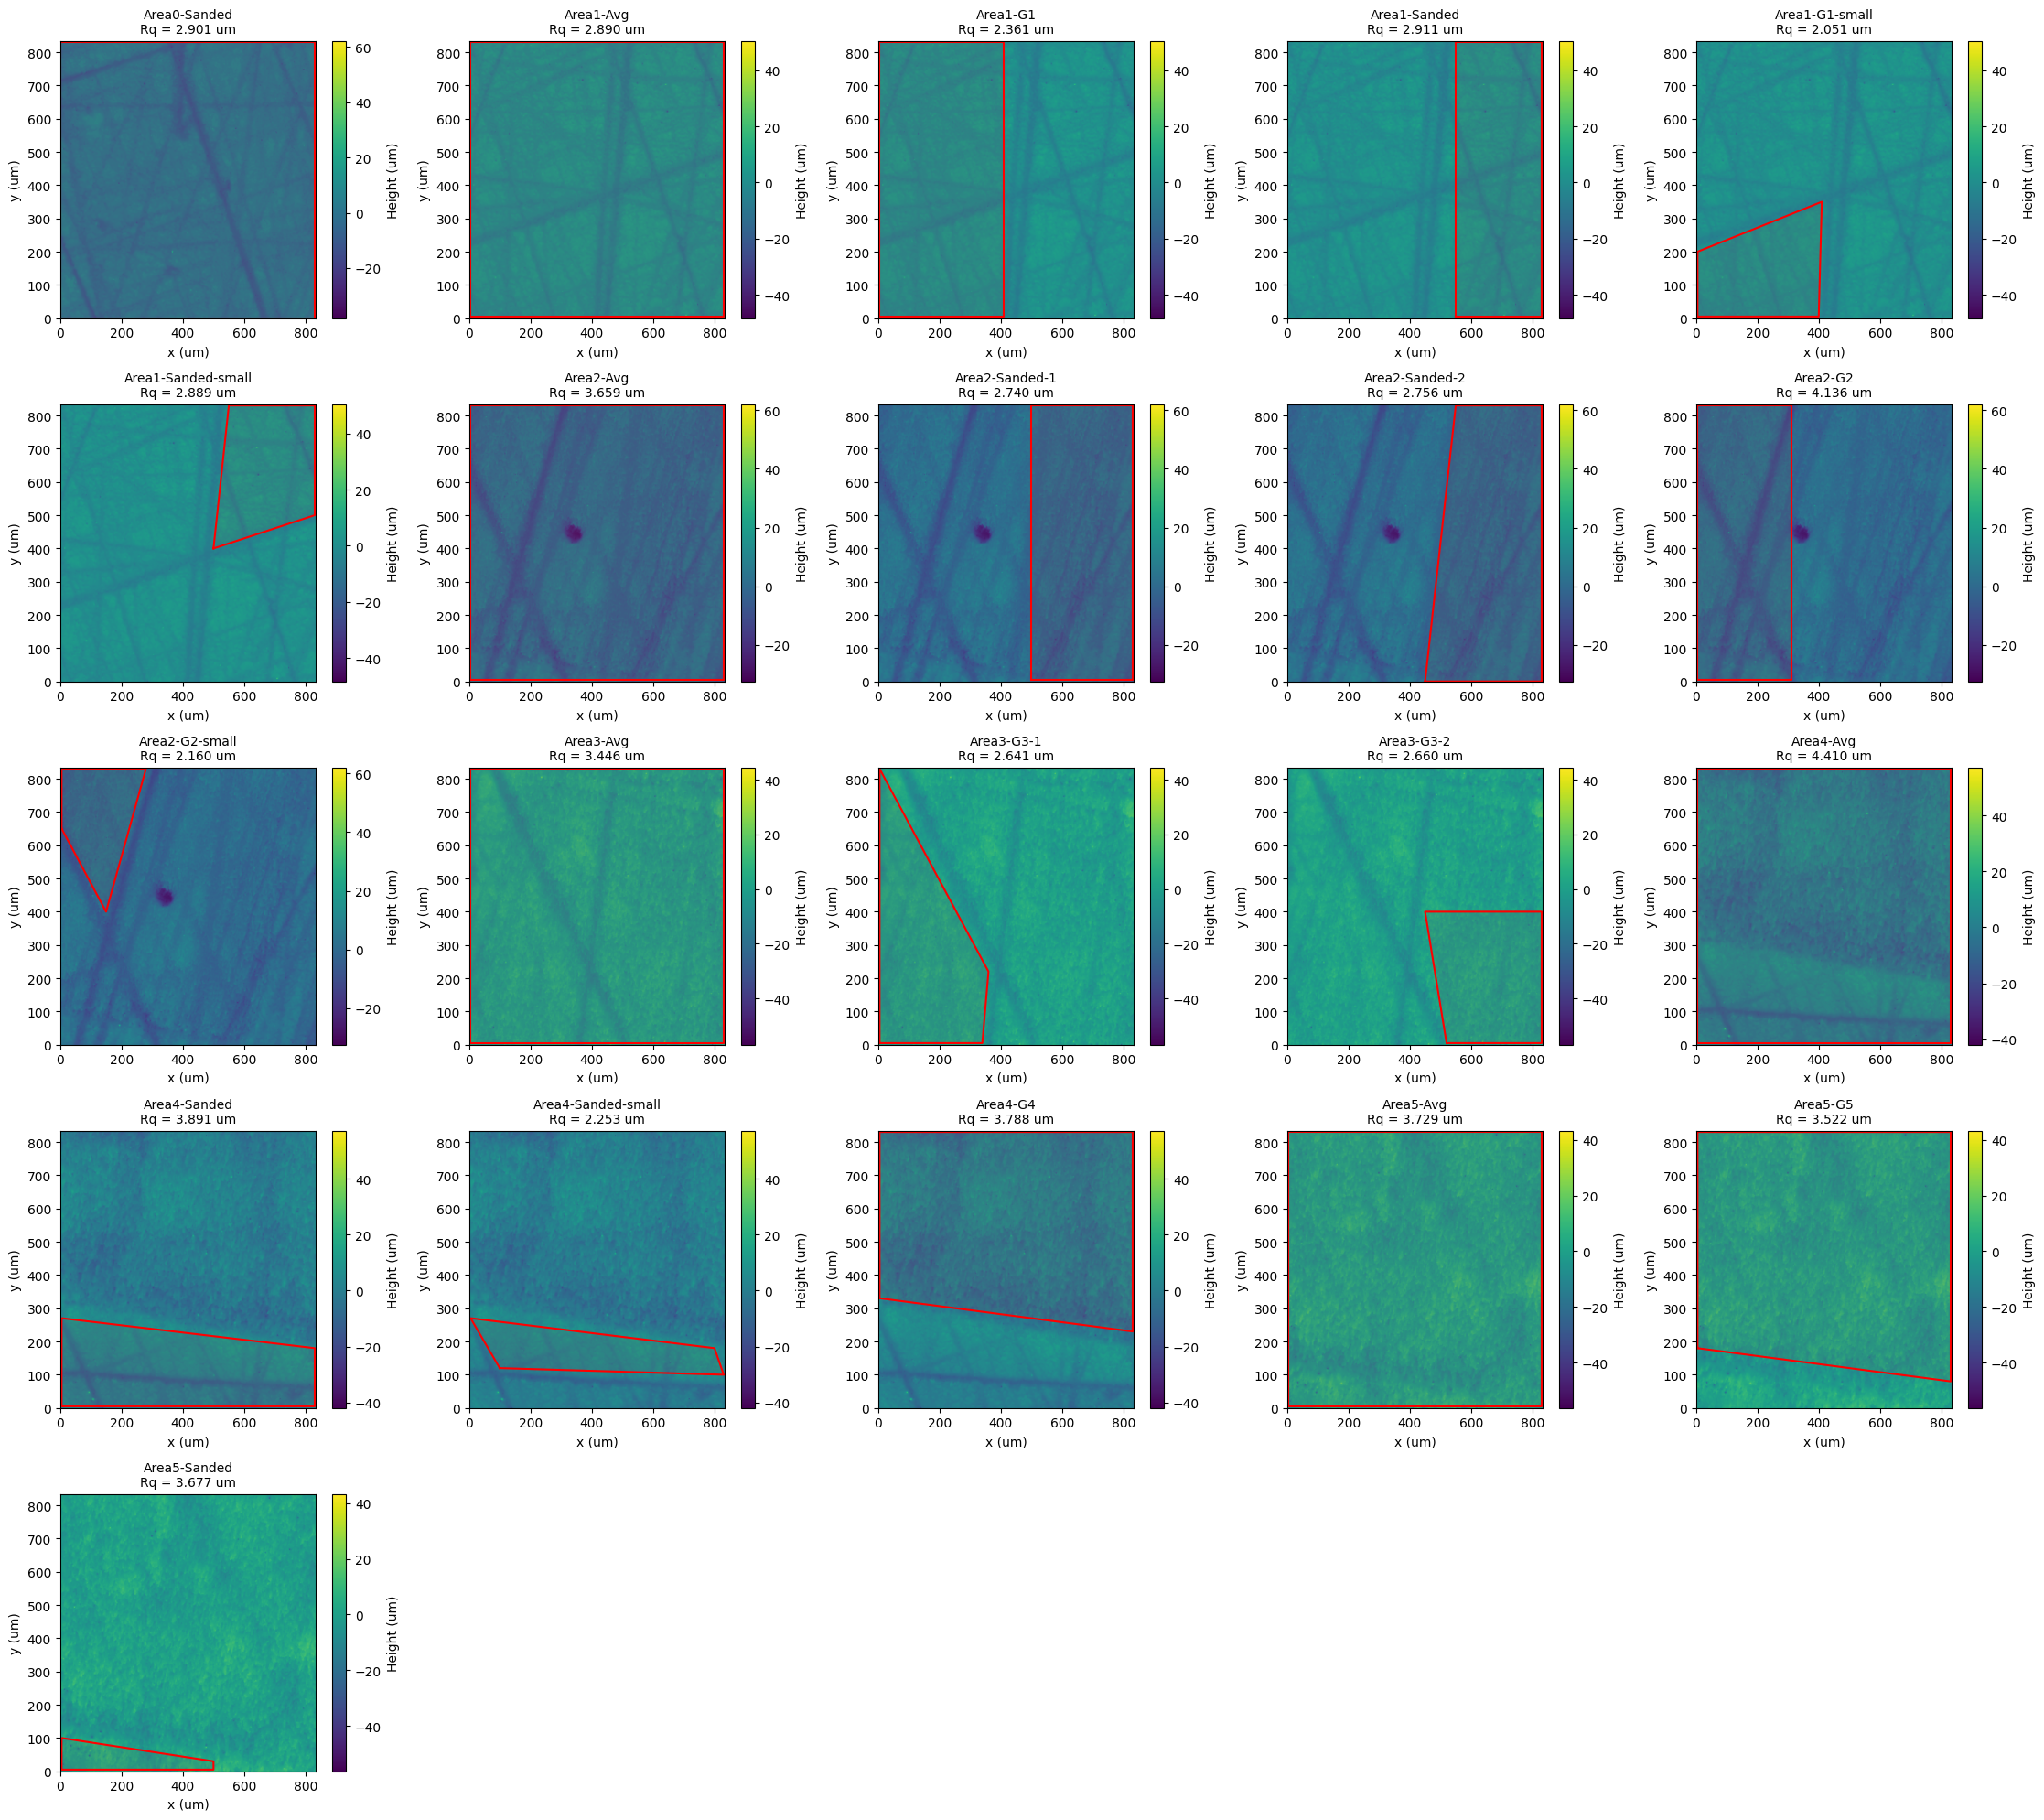

In [6]:
combined_surfaces = mic.build_surfaces(combined_sample_dict, data_root=DATA_ROOT)
combined_results, combined_fig = mic.analyze_surfaces(
    combined_surfaces,
    polygon_unit='um',
    roughness_unit='um',
    xy_unit='um',
    z_unit='um',
    max_cols=5,
    detrend=DETREND_ROI,
)
print(f"Aggregated {len(combined_results)} ROIs across {len(combined_sample_dict)} scan areas.")

### 4.1 Metrics table and normalization

The table below reflects detrended (plane-flattened) ROIs so the statistics capture only local texture.

In [7]:
combined_df = pd.DataFrame(combined_results)

split_cols = combined_df['label'].str.split('-', expand=True)
split_cols = split_cols.reindex(columns=range(3)).fillna('unknown')
combined_df['area'] = split_cols[0]
combined_df['treatment'] = split_cols[1]
combined_df['roi_fragment'] = split_cols[2]

combined_df = combined_df[['area', 'treatment', 'roi_fragment', 'label', 'Ra', 'Rq', 'Rz', 'mean']]
combined_df.sort_values(['treatment', 'area', 'roi_fragment'], inplace=True, ignore_index=True)

scaler = StandardScaler()
scaled = scaler.fit_transform(combined_df[['Ra', 'Rq', 'Rz', 'mean']])
scaled_df = pd.DataFrame(scaled, columns=['Ra_z', 'Rq_z', 'Rz_z', 'mean_z'])
combined_df = pd.concat([combined_df, scaled_df], axis=1)

display(combined_df)



,area,treatment,roi_fragment,label,Ra,Rq,Rz,mean,Ra_z,Rq_z,Rz_z,mean_z
0,Area1,Avg,unknown,Area1-Avg,2.295148,2.890180,98.847844,1.228771e-16,-0.276916,-0.342113,0.808362,0.228150
1,Area2,Avg,unknown,Area2-Avg,2.751199,3.659257,93.633572,-4.368583e-16,0.582605,0.814453,0.483182,0.226080
2,Area3,Avg,unknown,Area3-Avg,2.671374,3.445933,99.721039,5.499888e-16,0.432159,0.493648,0.862817,0.229731
3,Area4,Avg,unknown,Area4-Avg,3.543511,4.410469,99.080185,-2.552633e-16,2.075881,1.944151,0.822851,0.226751
4,Area5,Avg,unknown,Area5-Avg,2.942870,3.728972,99.522243,-4.283267e-16,0.943849,0.919293,0.850420,0.226111
5,Area1,G1,small,Area1-G1-small,1.619917,2.051384,51.350392,9.411454e-16,-1.549528,-1.603523,-2.153743,0.231178
6,Area1,G1,unknown,Area1-G1,1.867576,2.361497,79.837737,-1.847701e-16,-1.082764,-1.137165,-0.377174,0.227012
7,Area2,G2,small,Area2-G2-small,1.662365,2.159581,59.500122,-2.151136e-14,-1.469525,-1.440813,-1.645498,0.148107
8,Area2,G2,unknown,Area2-G2,3.322059,4.136253,87.135802,3.631540e-16,1.658509,1.531776,0.077959,0.229039
9,Area3,G3,1,Area3-G3-1,2.089212,2.641122,76.444587,5.551115e-16,-0.665044,-0.716655,-0.588783,0.229750


### 4.2 Overview figure

Full gallery of all scans with ROI overlays and annotated ``Rq`` values.

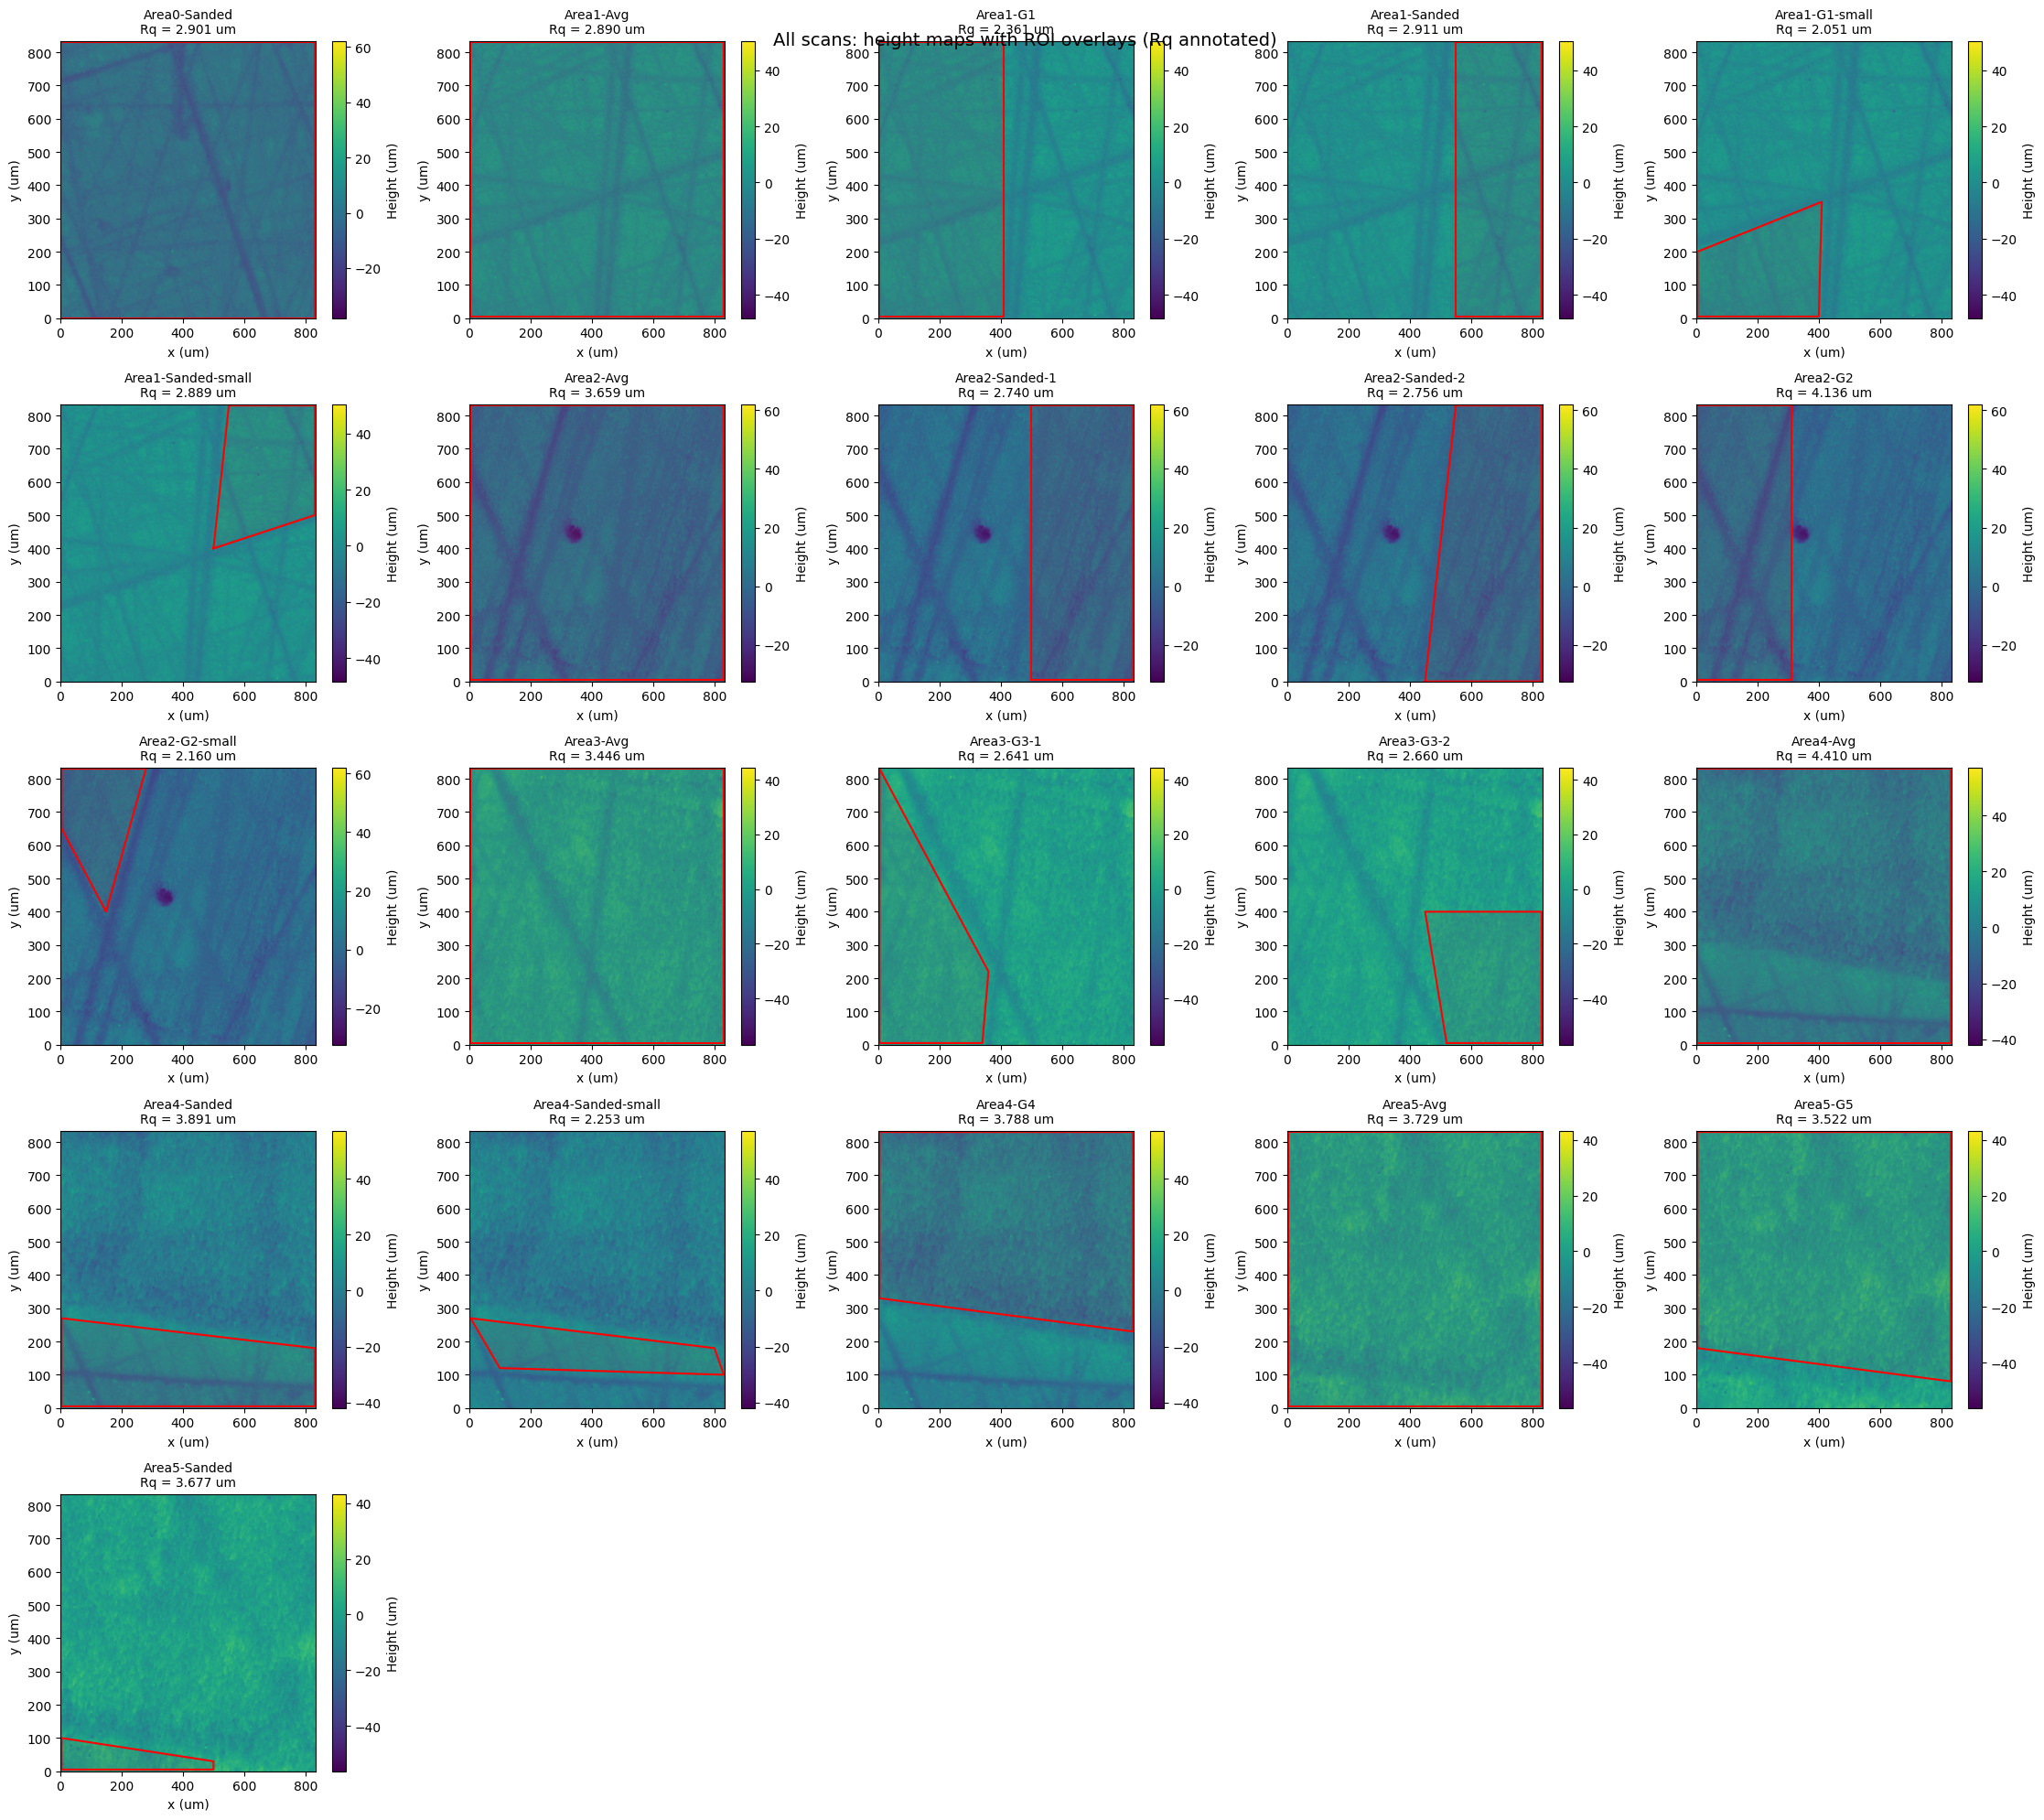

In [8]:
combined_fig.suptitle('All scans: height maps with ROI overlays (Rq annotated)', fontsize=14)
combined_fig

### 4.3 Metric summaries by category

Summaries and violin plots for each grouping (treatment, scan area, ROI fragment).

Rq                        Ra                         Rz  \
               mean       std count      mean       std count       mean   
treatment                                                                  
G4         3.787638       NaN     1  2.998777       NaN     1  94.945464   
Avg        3.626962  0.547940     5  2.840820  0.457900     5  98.160977   
G5         3.522374       NaN     1  2.781486       NaN     1  99.647232   
G2         3.147917  1.397718     2  2.492212  1.173581     2  73.317962   
Sanded     3.002118  0.530133     8  2.328548  0.401209     8  85.484289   
G3         2.650327  0.013019     2  2.099466  0.014501     2  78.252242   
G1         2.206441  0.219282     2  1.743746  0.175121     2  65.594064   

                            
                 std count  
treatment                   
G4               NaN     1  
Avg         2.554455     5  
G5               NaN     1  
G2         19.541377     2  
Sanded     18.115522     8  
G3          2.556411     2  
G1         20.143594     2

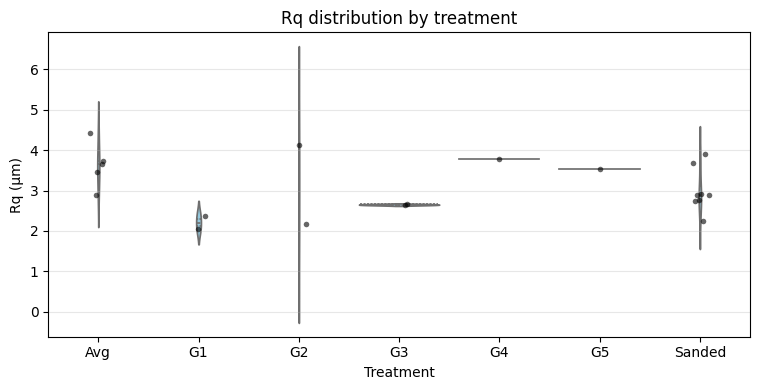

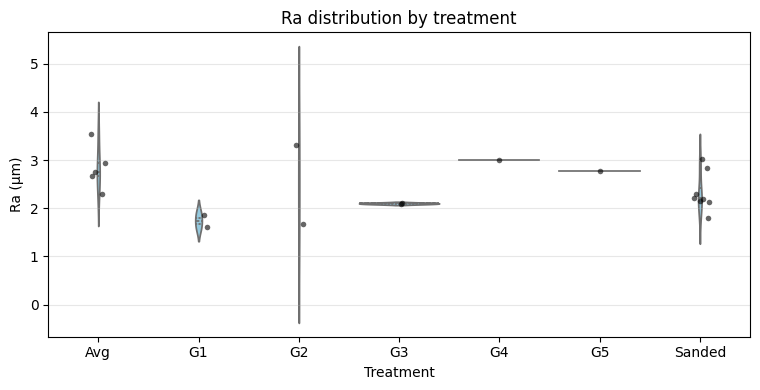

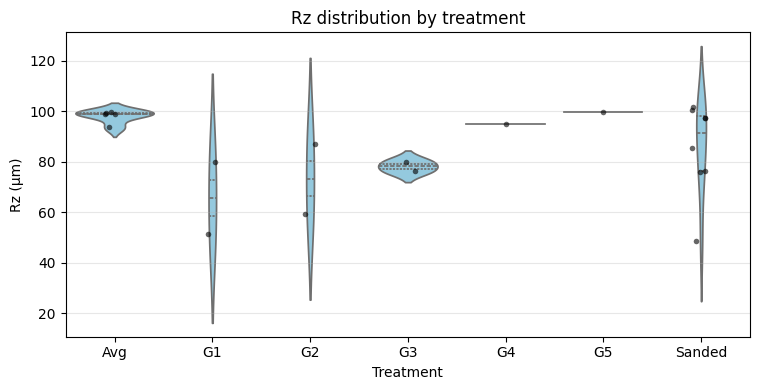

Rq                        Ra                          Rz  \
           mean       std count      mean       std count        mean   
area                                                                    
Area5  3.642753  0.107451     3  2.856203  0.081353     3   94.833438   
Area4  3.585377  0.929356     4  2.837197  0.741015     4   86.177844   
Area2  3.090299  0.793436     5  2.402741  0.643026     5   78.561725   
Area3  2.915529  0.459435     3  2.290102  0.330350     3   85.408508   
Area0  2.900887       NaN     1  2.195922       NaN     1  100.359928   
Area1  2.620481  0.393643     5  2.057253  0.300908     5   84.998933   

                        
             std count  
area                    
Area5   8.229728     3  
Area4  25.104649     4  
Area2  12.985957     5  
Area3  12.526134     3  
Area0        NaN     1  
Area1  20.384943     5

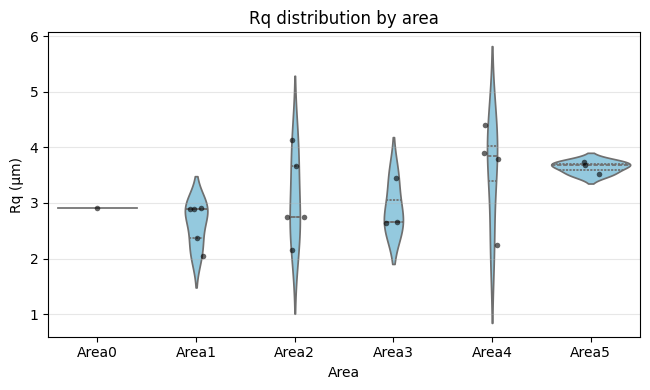

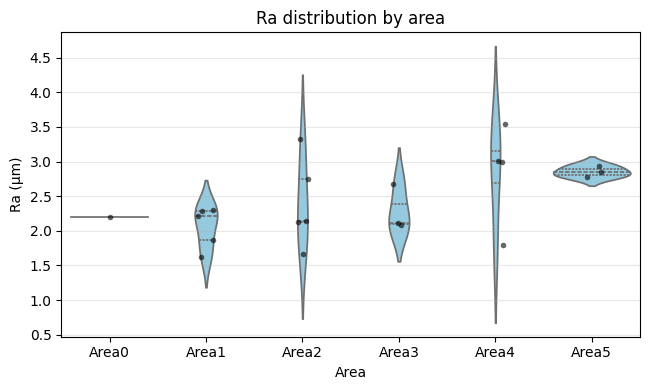

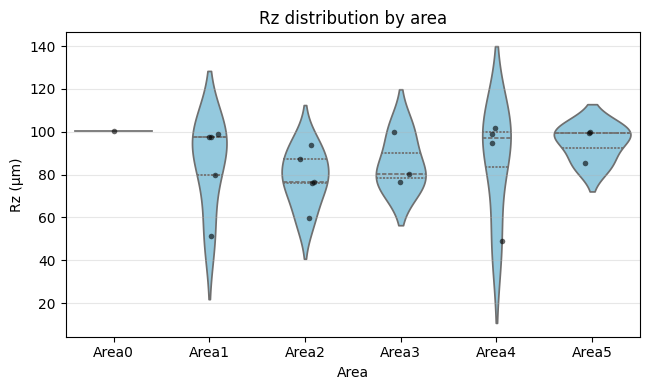

Rq                        Ra                         Rz  \
                  mean       std count      mean       std count       mean   
roi_fragment                                                                  
unknown       3.486294  0.573988    13  2.732016  0.469338    13  95.193995   
2             2.707911  0.068417     2  2.128394  0.026411     2  78.203720   
1             2.690618  0.069998     2  2.110113  0.029558     2  76.318087   
small         2.338063  0.376153     4  1.822594  0.272024     4  64.258721   

                               
                    std count  
roi_fragment                   
unknown        6.864536    13  
2              2.625032     2  
1              0.178899     2  
small         22.574299     4

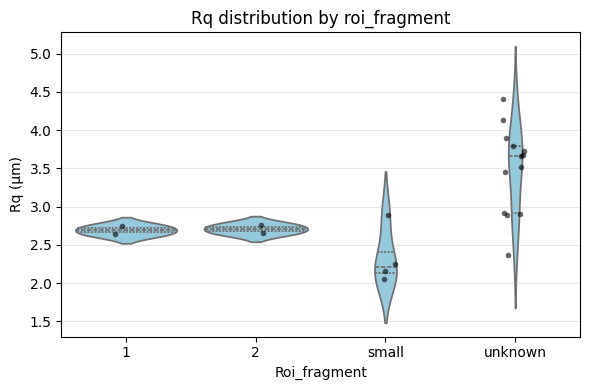

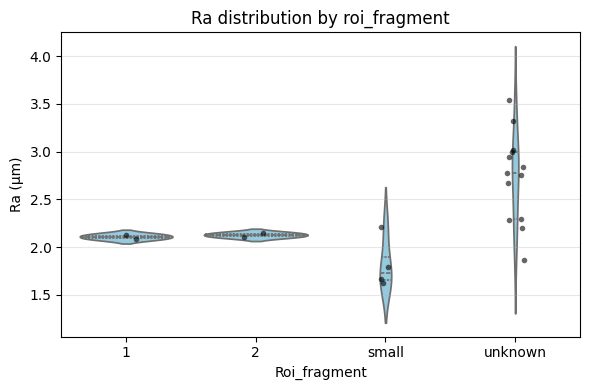

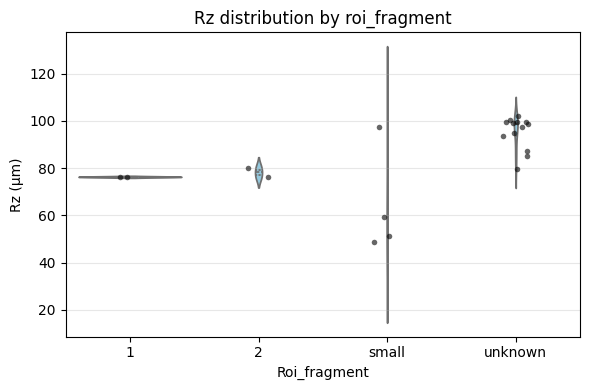

In [9]:
def summarize_and_plot(df, group_col, metrics=('Rq', 'Ra', 'Rz')):
    """Print mean/std/count tables and draw violin plots for the requested metrics."""
    summary = df.groupby(group_col)[list(metrics)].agg(['mean', 'std', 'count'])
    display(summary.sort_values((metrics[0], 'mean'), ascending=False))

    for metric in metrics:
        order = summary.index.tolist()
        fig, ax = plt.subplots(figsize=(max(6, len(order) * 1.1), 4))
        sns.violinplot(data=df, x=group_col, y=metric,
                       order=order, inner='quartile', ax=ax, color='skyblue')
        sns.stripplot(data=df, x=group_col, y=metric,
                      order=order, ax=ax, color='black', size=4, alpha=0.6)
        ax.set_title(f"{metric} distribution by {group_col}")
        ax.set_xlabel(group_col.capitalize())
        ax.set_ylabel(f"{metric} (µm)")
        ax.grid(axis='y', alpha=0.3)
        fig.tight_layout()
        plt.show()

summarize_and_plot(combined_df, 'treatment', metrics=('Rq', 'Ra', 'Rz'))
summarize_and_plot(combined_df, 'area', metrics=('Rq', 'Ra', 'Rz'))
summarize_and_plot(combined_df, 'roi_fragment', metrics=('Rq', 'Ra', 'Rz'))

### 4.4 Line plots per metric

Track each roughness metric across ROIs in sequence.

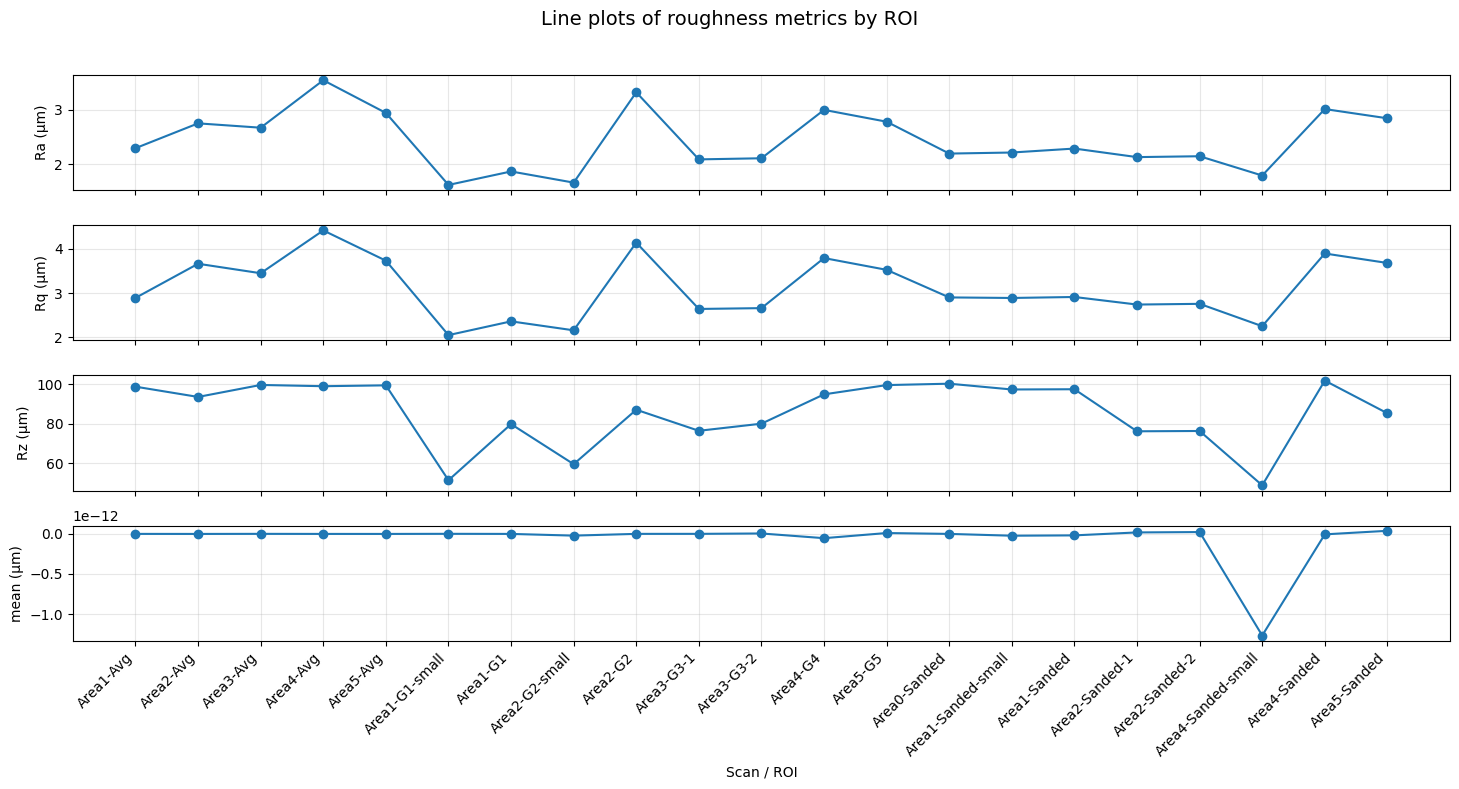

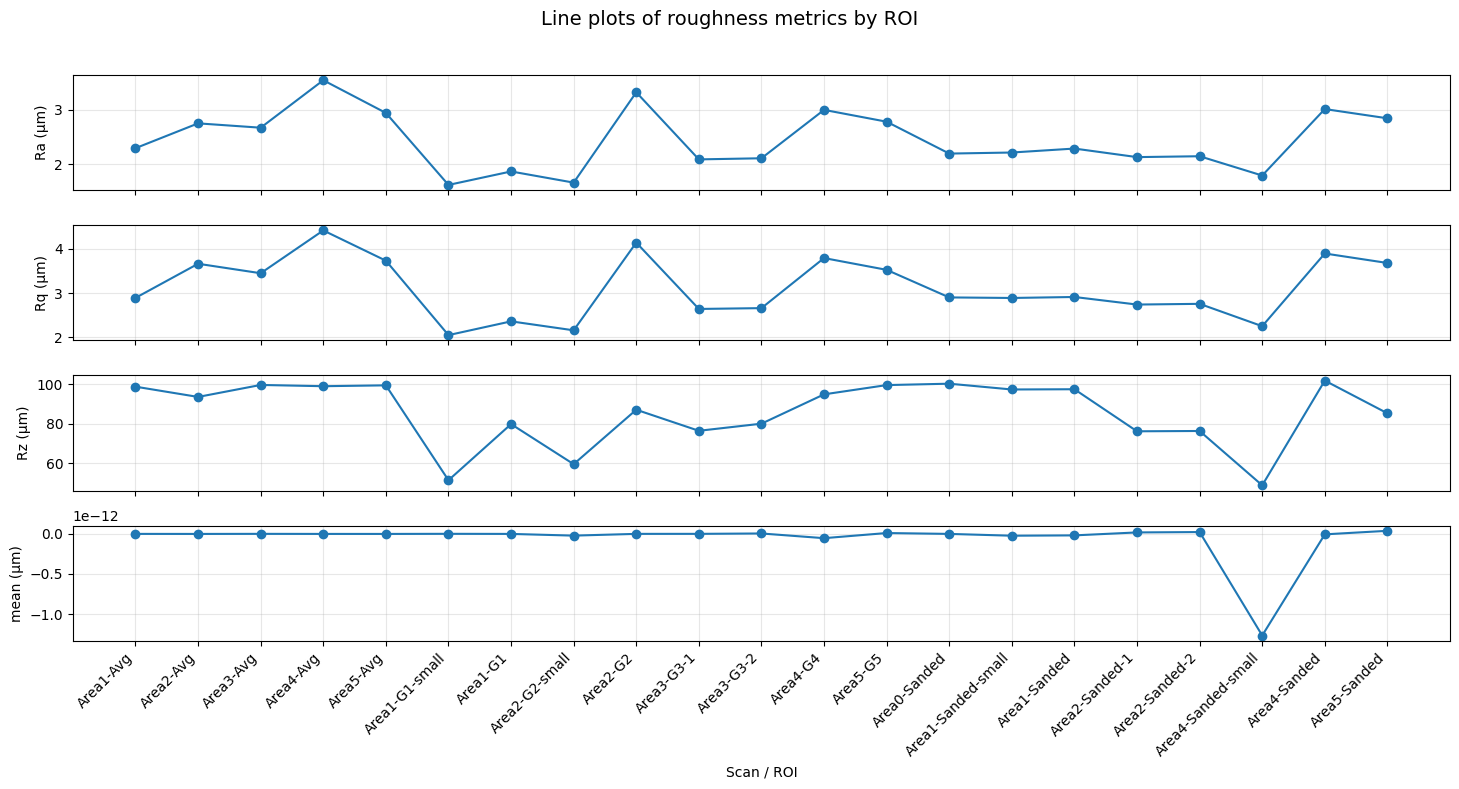

In [10]:
metric_names = ['Ra', 'Rq', 'Rz', 'mean']
fig_metrics, axes = plt.subplots(len(metric_names), 1,
                                 figsize=(max(8, len(combined_df) * 0.7), 2.0 * len(metric_names)),
                                 sharex=True)

x_vals = range(len(combined_df))
labels = combined_df['label']

for ax, metric in zip(axes, metric_names):
    ax.plot(x_vals, combined_df[metric], marker='o')
    ax.set_ylabel(f"{metric} (µm)")
    ax.grid(alpha=0.3)

axes[-1].set_xticks(list(x_vals))
axes[-1].set_xticklabels(labels, rotation=45, ha='right')
axes[-1].set_xlabel('Scan / ROI')
fig_metrics.suptitle('Line plots of roughness metrics by ROI', fontsize=14)
fig_metrics.tight_layout(rect=(0, 0, 1, 0.96))
fig_metrics



### 4.5 Heatmap of normalized metrics

A z-score heatmap highlights which ROIs deviate the most for each metric.

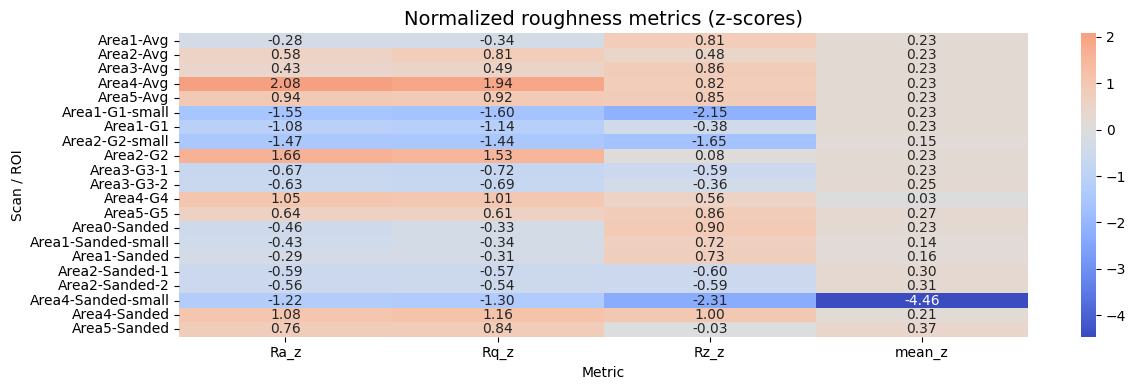

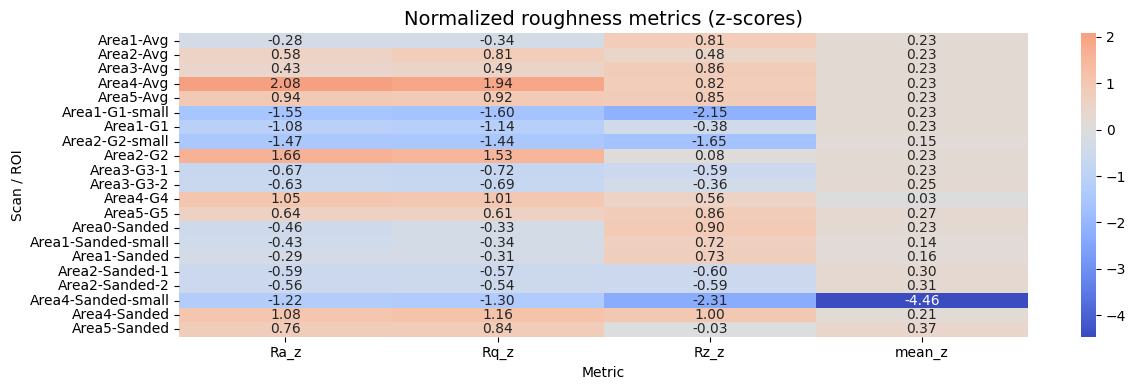

In [11]:
heatmap_data = combined_df.set_index('label')[['Ra_z', 'Rq_z', 'Rz_z', 'mean_z']]
fig_heatmap, ax_heatmap = plt.subplots(figsize=(max(6, heatmap_data.shape[0] * 0.6), 4))
sns.heatmap(heatmap_data, cmap='coolwarm', center=0, annot=True, fmt='.2f', ax=ax_heatmap)
ax_heatmap.set_title('Normalized roughness metrics (z-scores)', fontsize=14)
ax_heatmap.set_xlabel('Metric')
ax_heatmap.set_ylabel('Scan / ROI')
fig_heatmap.tight_layout()
fig_heatmap



### 4.6 Treatment comparison across scans

Box/strip plots show the spread of ``Rq`` for each treatment, and line plots track how ``Rq`` changes across scan areas.

Rq summary by treatment (µm):


,mean,std,count
treatment,,,
G4,3.787638,NaN,1
Avg,3.626962,0.547940,5
G5,3.522374,NaN,1
G2,3.147917,1.397718,2
Sanded,3.002118,0.530133,8
G3,2.650327,0.013019,2
G1,2.206441,0.219282,2


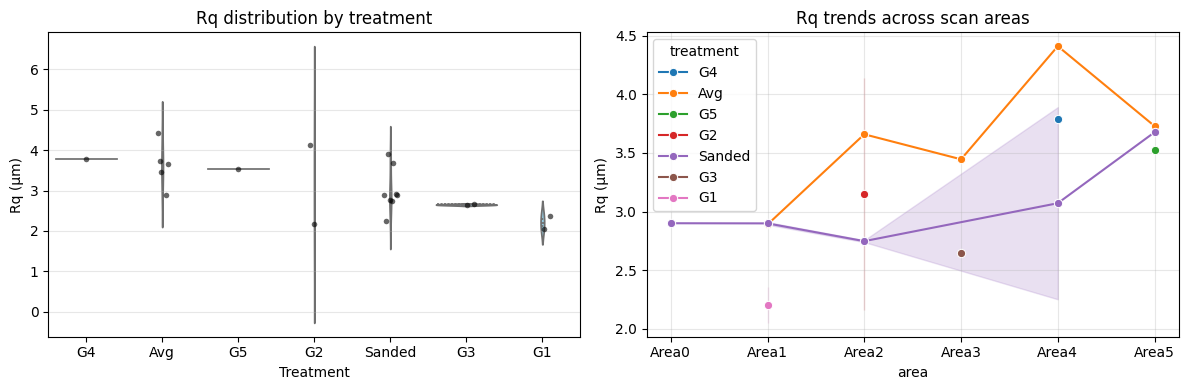

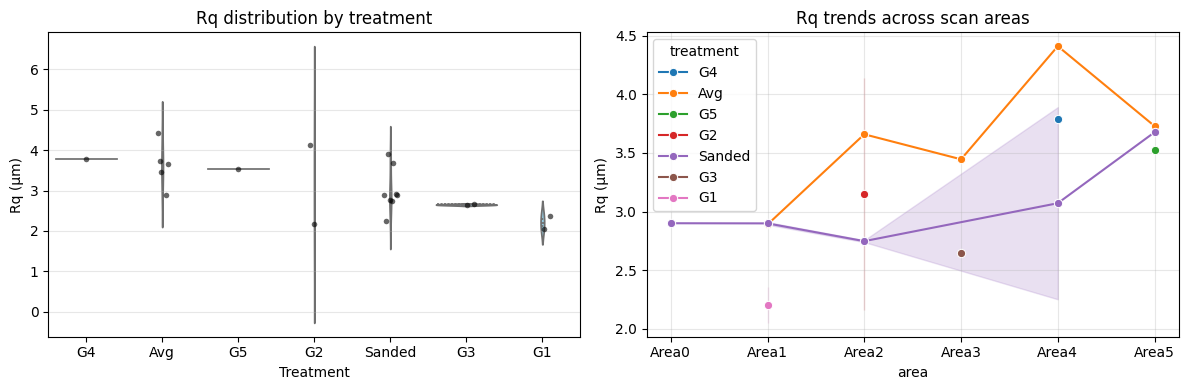

In [12]:
summary = (combined_df.groupby('treatment')['Rq']
           .agg(['mean', 'std', 'count'])
           .sort_values('mean', ascending=False))
print('Rq summary by treatment (µm):')
display(summary)

treatment_order = summary.index.tolist()

fig_compare, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

sns.violinplot(data=combined_df, x='treatment', y='Rq', order=treatment_order,
               inner='quartile', ax=axes[0], color='skyblue')
sns.stripplot(data=combined_df, x='treatment', y='Rq', order=treatment_order,
              ax=axes[0], color='black', size=4, alpha=0.6)
axes[0].set_title('Rq distribution by treatment')
axes[0].set_xlabel('Treatment')
axes[0].set_ylabel('Rq (µm)')
axes[0].grid(alpha=0.3, axis='y')

sns.lineplot(data=combined_df.sort_values('area'), x='area', y='Rq', hue='treatment',
             marker='o', ax=axes[1], hue_order=treatment_order)
axes[1].set_title('Rq trends across scan areas')
axes[1].set_ylabel('Rq (µm)')
axes[1].grid(alpha=0.3)
fig_compare.tight_layout()
fig_compare



### 4.7 Parallel coordinates plot

Compare all absolute roughness metrics per ROI on shared axes.

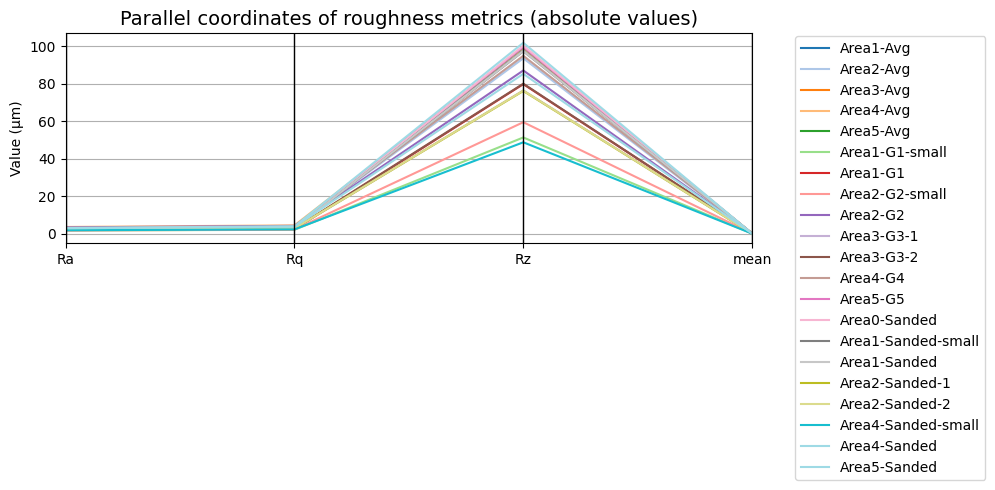

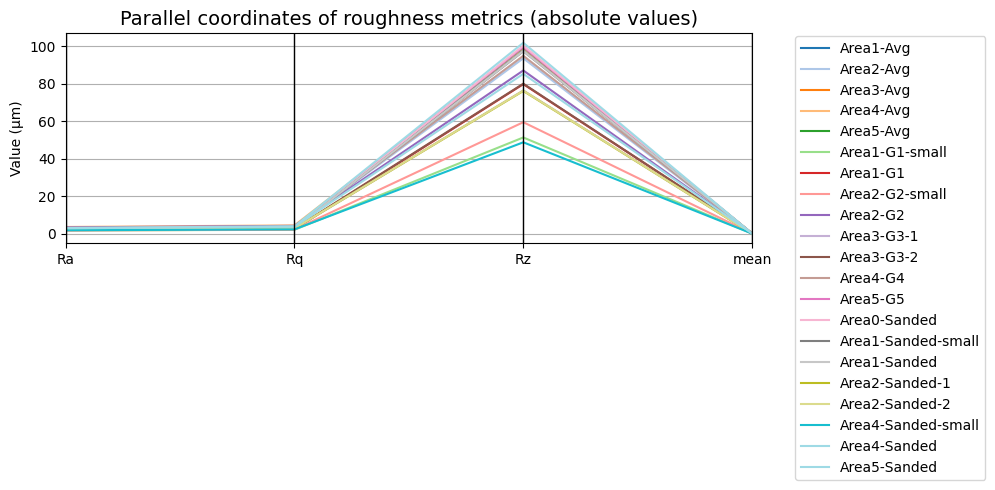

In [13]:
from pandas.plotting import parallel_coordinates

metric_names = ['Ra', 'Rq', 'Rz', 'mean']
parallel_df = combined_df[['label'] + metric_names].copy()
fig_parallel, ax_parallel = plt.subplots(figsize=(max(6, len(parallel_df) * 0.5), 4))
parallel_coordinates(parallel_df, 'label', ax=ax_parallel, colormap='tab20')
ax_parallel.set_title('Parallel coordinates of roughness metrics (absolute values)', fontsize=14)
ax_parallel.set_ylabel('Value (µm)')
ax_parallel.set_xticks(range(len(metric_names)))
ax_parallel.set_xticklabels(metric_names)
ax_parallel.legend(loc='upper right', bbox_to_anchor=(1.35, 1.02))
fig_parallel.tight_layout()
fig_parallel



### 4.8 PCA scatter plot

A two-component PCA of the normalized metrics reveals clusters or drifts in the combined roughness feature space.

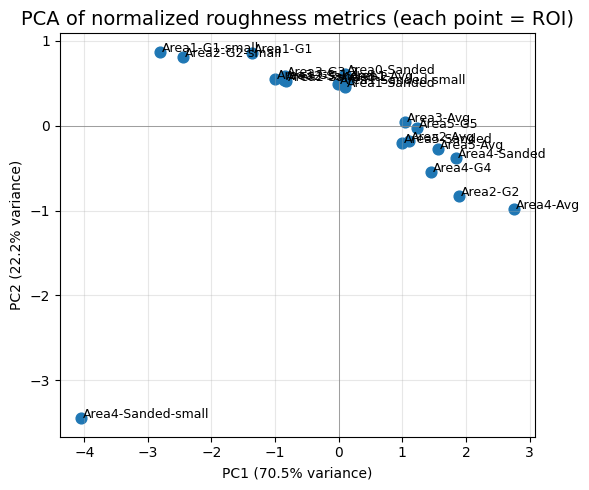

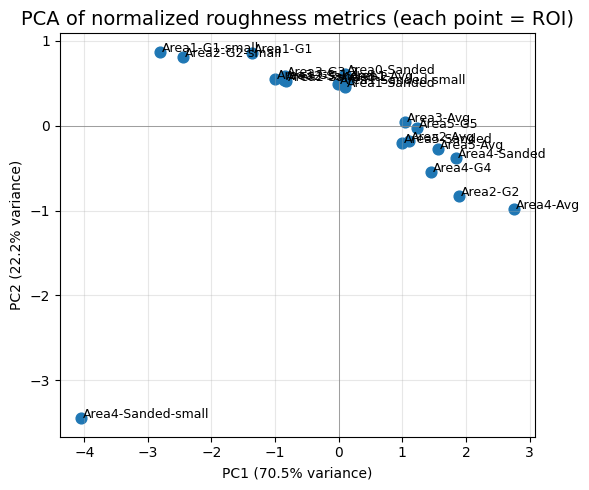

In [14]:
from sklearn.decomposition import PCA

metric_names = ['Ra', 'Rq', 'Rz', 'mean']
scaled_metrics = combined_df[[f'{c}_z' for c in metric_names]].values
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(scaled_metrics)
fig_pca, ax_pca = plt.subplots(figsize=(6, 5))
ax_pca.scatter(pca_coords[:, 0], pca_coords[:, 1], s=60)
for (x, y), label in zip(pca_coords, combined_df['label']):
    ax_pca.text(x + 0.03, y, label, fontsize=9)
ax_pca.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax_pca.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax_pca.set_title('PCA of normalized roughness metrics (each point = ROI)', fontsize=14)
ax_pca.axhline(0, color='grey', linewidth=0.5)
ax_pca.axvline(0, color='grey', linewidth=0.5)
ax_pca.grid(alpha=0.3)
fig_pca.tight_layout()
fig_pca

